In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
import os
os.getcwd()

'c:\\Users\\S\\Desktop\\labmentix(AIML internship)\\Tourism_Experience_Analytics\\attraction_reccomendation.ipynb\\content_based_recemmendation'

In [3]:
data=pd.read_csv("../../Data/final_data.csv")
data.head()

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,visitmodex,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry
0,14,Europe,Southern Europe,Portugal,Lagos,5661,2018,12,640,4,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
1,14,Europe,Southern Europe,Portugal,Lagos,67652,2018,12,748,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
2,14,Europe,Southern Europe,Portugal,Lagos,68777,2018,12,748,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
3,16,Asia,South East Asia,Indonesia,Jakarta,4735,2018,4,640,5,Family,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
4,16,Asia,South East Asia,Indonesia,Jakarta,5318,2017,12,640,5,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon


In [4]:
data=data.drop_duplicates(subset=["useridx","attractionidx","visitmodex"],keep="first")
data.shape

(46765, 16)

In [5]:
data.head(4)

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,visitmodex,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry
0,14,Europe,Southern Europe,Portugal,Lagos,5661,2018,12,640,4,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
1,14,Europe,Southern Europe,Portugal,Lagos,67652,2018,12,748,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
3,16,Asia,South East Asia,Indonesia,Jakarta,4735,2018,4,640,5,Family,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
4,16,Asia,South East Asia,Indonesia,Jakarta,5318,2017,12,640,5,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon


In [6]:
data.ratingx.describe()

count    46765.000000
mean         4.166599
std          0.972804
min          1.000000
25%          4.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: ratingx, dtype: float64

In [7]:
average_attraction_rating=data.groupby("attraction")["ratingx"].median()
average_attraction_rating.head()

attraction
Balekambang Beach                     4.0
Bromo Tengger Semeru National Park    5.0
Coban Rondo Waterfall                 4.0
Goa Cina Beach                        4.0
Jodipan Colorful Village              5.0
Name: ratingx, dtype: float64

In [8]:
data["average_atttraction_rating"]=data.set_index("attraction").index.map(average_attraction_rating).fillna(data.ratingx.median())

In [9]:
data.info()

<class 'pandas.DataFrame'>
Index: 46765 entries, 0 to 52929
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   useridx                     46765 non-null  int64  
 1   continent                   46765 non-null  str    
 2   region                      46765 non-null  str    
 3   usercountry                 46765 non-null  str    
 4   usercity                    46757 non-null  str    
 5   transactionid               46765 non-null  int64  
 6   visityearx                  46765 non-null  int64  
 7   visitmonthx                 46765 non-null  int64  
 8   attractionidx               46765 non-null  int64  
 9   ratingx                     46765 non-null  int64  
 10  visitmodex                  46765 non-null  str    
 11  attraction                  46765 non-null  str    
 12  attractionaddress           46765 non-null  str    
 13  attractiontype              46765 non-null  str

In [10]:
data.dropna(inplace=True)
data=data.reset_index(drop=True)
data.shape

(46757, 17)

In [11]:
data.attractiontype.value_counts(),data.attraction.nunique()

(attractiontype
 Nature & Wildlife Areas           12055
 Beaches                           10375
 Religious Sites                    6388
 Water Parks                        5828
 Points of Interest & Landmarks     5821
 Waterfalls                         2226
 Volcanos                           1078
 Flea & Street Markets               620
 History Museums                     558
 Historic Sites                      508
 National Parks                      469
 Ancient Ruins                       355
 Ballets                             250
 Caverns & Caves                     124
 Neighborhoods                        43
 Speciality Museums                   31
 Spas                                 28
 Name: count, dtype: int64,
 30)

In [12]:
data.attraction.nunique()

30

<Axes: xlabel='attractiontype'>

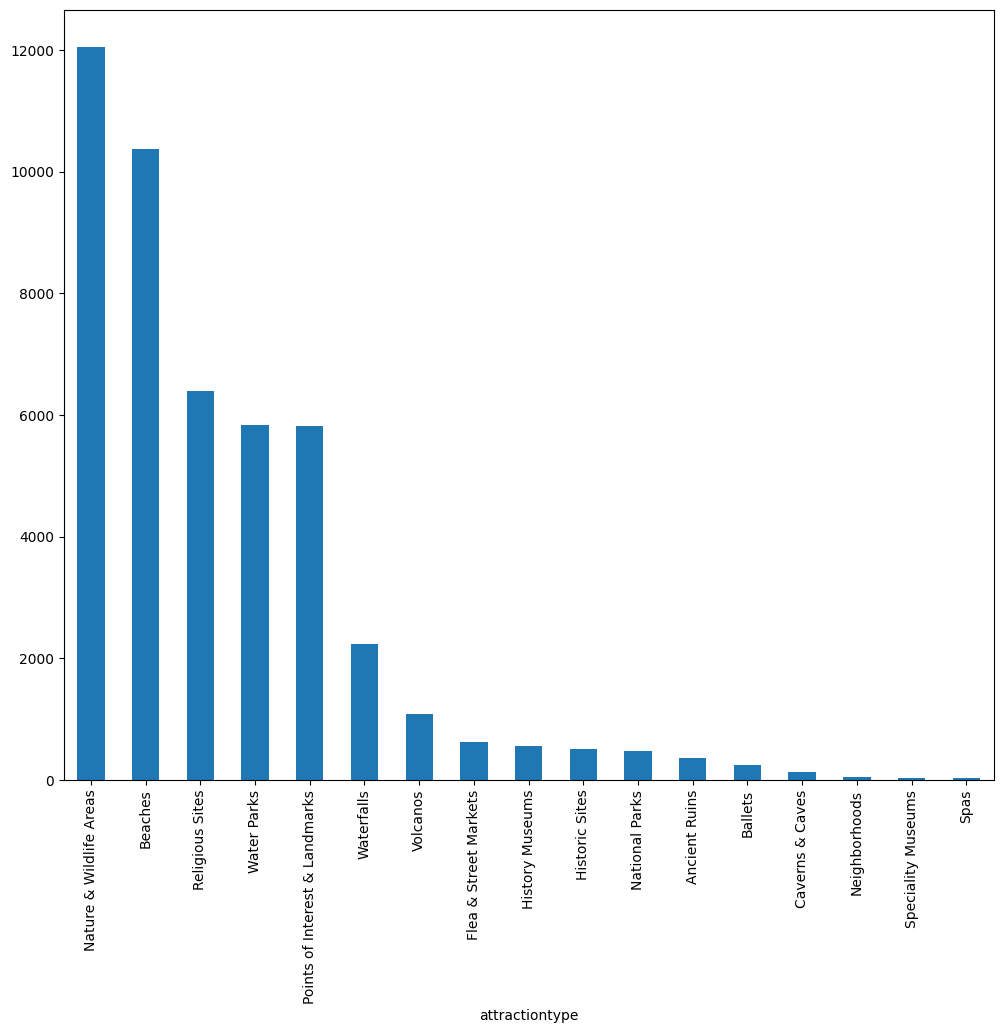

In [13]:
plt.figure(figsize=(12,10))
data.attractiontype.value_counts().plot(kind="bar")

<Axes: xlabel='attractioncity'>

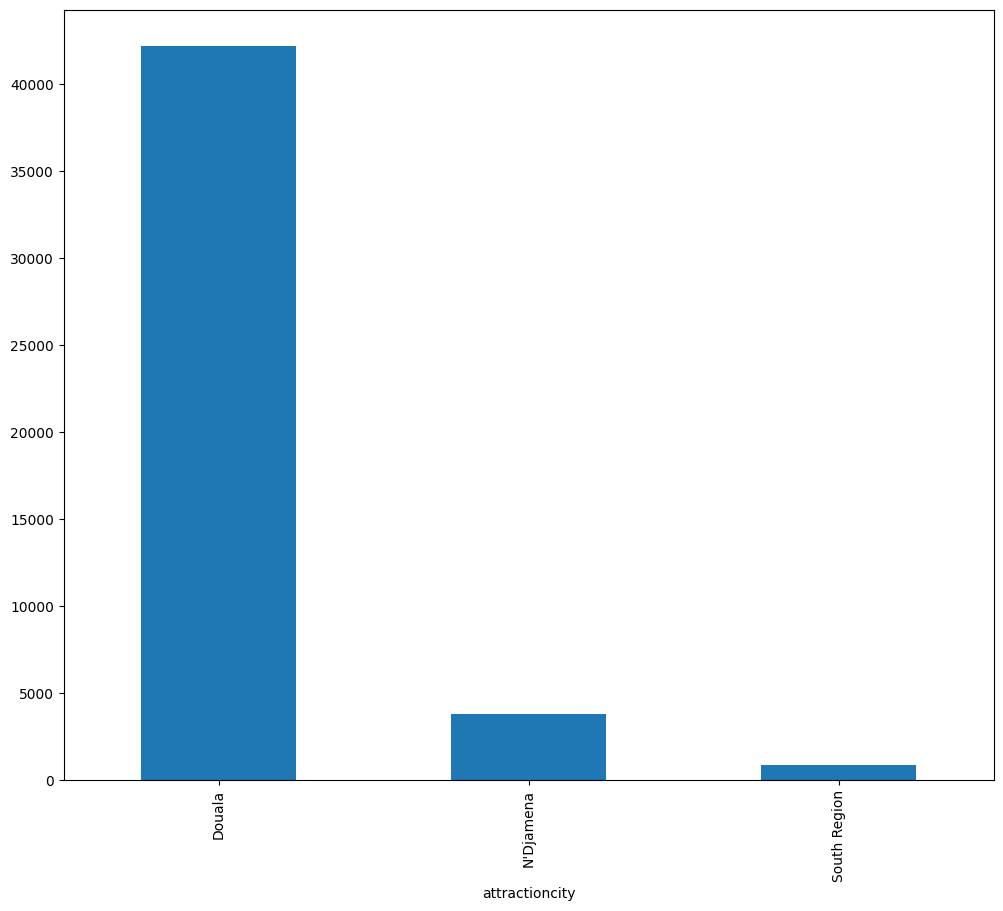

In [14]:
plt.figure(figsize=(12,10))
data.attractioncity.value_counts().plot(kind="bar")

In [15]:
data.attractioncountry.value_counts()

attractioncountry
Cameroon    43006
Chad         3751
Name: count, dtype: int64

In [16]:
data=data.iloc[:,9:]
data.head()

,ratingx,visitmodex,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry,average_atttraction_rating
0,4,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon,4.0
1,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon,4.0
2,5,Family,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon,4.0
3,5,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon,4.0
4,3,Couples,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon,4.0


In [17]:
import re 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

In [18]:
x=data["attraction"]
x.head(10)

0    Sacred Monkey Forest Sanctuary
1           Tegalalang Rice Terrace
2    Sacred Monkey Forest Sanctuary
3    Sacred Monkey Forest Sanctuary
4    Sacred Monkey Forest Sanctuary
5                     Waterbom Bali
6                    Nusa Dua Beach
7                    Uluwatu Temple
8           Tegalalang Rice Terrace
9                     Waterbom Bali
Name: attraction, dtype: str

#### Tokenization

In [19]:
tokens=[]
for i in x:
    a=re.sub("[^a-zA-Z0-9]"," ",i)
    a=a.lower().strip().split()
    tokens.append(a)
tokens[:5]

[['sacred', 'monkey', 'forest', 'sanctuary'],
 ['tegalalang', 'rice', 'terrace'],
 ['sacred', 'monkey', 'forest', 'sanctuary'],
 ['sacred', 'monkey', 'forest', 'sanctuary'],
 ['sacred', 'monkey', 'forest', 'sanctuary']]

#### Stoword removal

In [20]:
word=stopwords.words("english")
word[:10]

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [21]:
for i in tokens[:2]:
    for j in i:
        print(j)

sacred
monkey
forest
sanctuary
tegalalang
rice
terrace


In [22]:
cleaned=[]
for i in tokens:
    words=[]
    for j in i:
        if j not in words and j not in word and j!="":
            words.append(j)
    cleaned.append(words)
cleaned[:5]

[['sacred', 'monkey', 'forest', 'sanctuary'],
 ['tegalalang', 'rice', 'terrace'],
 ['sacred', 'monkey', 'forest', 'sanctuary'],
 ['sacred', 'monkey', 'forest', 'sanctuary'],
 ['sacred', 'monkey', 'forest', 'sanctuary']]

#### Lemmatization(Base word extraction)

In [23]:
for i in cleaned[:2]:
    print(pos_tag(i))
text=pos_tag(cleaned[1])
text[0]

[('sacred', 'JJ'), ('monkey', 'NN'), ('forest', 'JJS'), ('sanctuary', 'NN')]
[('tegalalang', 'NN'), ('rice', 'NN'), ('terrace', 'NN')]


('tegalalang', 'NN')

In [24]:
pos_tagging=[]
for i in cleaned:
    pos_tagging.append(pos_tag(i))
pos_tagging[:3]

[[('sacred', 'JJ'), ('monkey', 'NN'), ('forest', 'JJS'), ('sanctuary', 'NN')],
 [('tegalalang', 'NN'), ('rice', 'NN'), ('terrace', 'NN')],
 [('sacred', 'JJ'), ('monkey', 'NN'), ('forest', 'JJS'), ('sanctuary', 'NN')]]

In [25]:
from nltk.corpus import wordnet
def get_word_pos(treebank_tag):
    if treebank_tag.startswith("N"):
        return wordnet.NOUN
    elif treebank_tag.startswith("J"):
        return wordnet.ADJ
    elif treebank_tag.startswith("V"):
        return wordnet.VERB
    elif treebank_tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [26]:
lemmatize=WordNetLemmatizer()
lemmed=[]
for i in pos_tagging:
    lemma=[]
    for word,treebank_tag in i:
        lemma.append(lemmatize.lemmatize(word,get_word_pos(treebank_tag)))
    lemmed.append(lemma)
lemmed[:5]

[['sacred', 'monkey', 'forest', 'sanctuary'],
 ['tegalalang', 'rice', 'terrace'],
 ['sacred', 'monkey', 'forest', 'sanctuary'],
 ['sacred', 'monkey', 'forest', 'sanctuary'],
 ['sacred', 'monkey', 'forest', 'sanctuary']]

#### Text Vectorization

In [27]:
final_sentence=[]
for i in lemmed:
    final_sentence.append(" ".join(i))
final_sentence[:5]

['sacred monkey forest sanctuary',
 'tegalalang rice terrace',
 'sacred monkey forest sanctuary',
 'sacred monkey forest sanctuary',
 'sacred monkey forest sanctuary']

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
tfidf=TfidfVectorizer()
final_sentence=tfidf.fit_transform(final_sentence)

In [30]:
import joblib
joblib.dump(final_sentence,"final_sentence.pkl")

['final_sentence.pkl']

In [31]:
a=final_sentence[:1].toarray()
a

array([[0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0.5, 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. ]])

In [32]:
from sklearn.metrics.pairwise import cosine_similarity

In [33]:
def preprocess(desc):
    words=[]
    desc=re.sub("[^a-zA-Z0-9]"," ",desc)
    desc=desc.lower().strip().split(" ")
    for i in desc:
        if i not in words and i!="" and i not in  word:
            words.append(i)
    lemmed=[]
    postag=pos_tag(words)
    lemmed=[lemmatize.lemmatize(words,get_word_pos(pos)) for words,pos in postag]
    final=[" ".join(lemmed)]
    vector=tfidf.transform(final)
    return np.round(cosine_similarity(vector,final_sentence),4)

In [34]:
re.sub("[^a-zA-Z0-9]"," ","@@@Sacred::: Monkey Forest Sanctuary !!!!").lower().strip().split()

['sacred', 'monkey', 'forest', 'sanctuary']

In [35]:
cs=preprocess("@@@Sacred::: Monkey Forest Sanctuary !!!!")
cs

array([[1., 0., 1., ..., 1., 0., 0.]], shape=(1, 46757))

In [36]:
cs.sum()

np.float64(12002.0)

In [37]:
data.attractioncity=data.attractioncity.str.lower().str.strip()
data.attractiontype=data.attractiontype.str.lower().str.strip()
data["cosine_similarity"]=cs.T
data.head(3)

,ratingx,visitmodex,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry,average_atttraction_rating,cosine_similarity
0,4,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",nature & wildlife areas,douala,Cameroon,4.0,1.0
1,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",points of interest & landmarks,douala,Cameroon,4.0,0.0
2,5,Family,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",nature & wildlife areas,douala,Cameroon,4.0,1.0


In [38]:
def recommend(data,desc,attractioncity,attractiontype):
    words=[]
    desc=re.sub("[^a-zA-Z0-9]"," ",desc)
    desc=desc.lower().strip().split(" ")
    for i in desc:
        if i not in words and i!="" and i not in  word:   
            words.append(i)
    lemmed=[]
    postag=pos_tag(words)
    lemmed=[lemmatize.lemmatize(words,get_word_pos(pos)) for words,pos in postag]
    final=[" ".join(lemmed)]
    vector=tfidf.transform(final)
    cs=np.round(cosine_similarity(vector,final_sentence),4)
    data["cosine_similarity"]=cs.T
    data=data[data.attraction.str.lower()!=final[0]]
    data=data[data["attractioncity"]==attractioncity]
    recommendations=data.sort_values(
        ["cosine_similarity","ratingx"]
        ,ascending=False).reset_index()
    return pd.DataFrame(recommendations[["attraction","attractionaddress"]].head(5))

In [39]:
desc="@@@Sacred::: Monkey Forest Sanctuary !!!!"
print(recommend(data,desc,"douala","water parks"))

                attraction                                  attractionaddress
0  Tegalalang Rice Terrace      Jalan Raya Ceking, Tegalalang 80517 Indonesia
1            Waterbom Bali            Jl. Kartika Plaza, Kuta 80361 Indonesia
2           Nusa Dua Beach     Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia
3           Uluwatu Temple  Jl. Raya Uluwatu Southern part of Bali, Pecatu...
4  Tegalalang Rice Terrace      Jalan Raya Ceking, Tegalalang 80517 Indonesia
